### Dataset Link :- https://universe.roboflow.com/universidadde-de-trsosmontes-e-alto-douro/rotten-apples-detection

Dataset Name :- Good & Rotten Apples

In [44]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="OW0NGyO0XjTOUAZ7RAiE")
project = rf.workspace("universidadde-de-trsosmontes-e-alto-douro").project("rotten-apples-detection")
version = project.version(5)
dataset = version.download("folder")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


loading Roboflow workspace...
loading Roboflow project...


In [45]:
!pip install tensorflow


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import os
print(os.getcwd())

c:\Users\Jagdish singh\DEEP-LEARNING\Image_Classification


In [47]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

In [48]:
import os

base_dir = r"C:\Users\Jagdish singh\DEEP-LEARNING\Image_Classification\Rotten-apples-detection-5"

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'valid')

In [49]:
print(os.path.exists(train_dir))
print(os.path.exists(val_dir))
print(os.listdir(base_dir))

True
True
['README.dataset.txt', 'README.roboflow.txt', 'train', 'valid']


In [50]:
# 1. Load and preprocess data
img_size = 224
batch_size = 16

In [51]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

In [52]:
!cd Rotten-apples-detection-5

In [53]:
%cd /content/Rotten-apples-detection-5/train

[WinError 3] The system cannot find the path specified: '/content/Rotten-apples-detection-5/train'
c:\Users\Jagdish singh\DEEP-LEARNING\Image_Classification


In [54]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [55]:
!rm -rf 'Good Apple Rotten Apple'

'rm' is not recognized as an internal or external command,
operable program or batch file.


In [69]:
train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(img_size, img_size), batch_size=batch_size, class_mode='categorical')

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(img_size, img_size), batch_size=batch_size, class_mode='categorical')

Found 777 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [70]:
train_gen.num_classes

2

In [71]:
# 2. Load VGG16 base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False  # Freeze convolutional base

# 3. Add custom classification head
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_gen.num_classes, activation='softmax')(x)

In [72]:
model = Model(inputs=base_model.input, outputs=predictions)

In [73]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,338 (68.38 MB)

 Trainable params: 3,211,650 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [74]:
# 4. Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [62]:
!pip install scipy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
# 5. Train model
history = model.fit(train_gen, epochs=2, validation_data=val_gen)

Epoch 1/2
49/49 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.6190 - loss: 1.0275 - val_accuracy: 0.7100 - val_loss: 0.4902
Epoch 2/2
49/49 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.7104 - loss: 0.5417 - val_accuracy: 0.9800 - val_loss: 0.2035


In [76]:
# 6. Evaluate model
loss, acc = model.evaluate(val_gen)
print(f"Test Accuracy: {acc:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9800 - loss: 0.2035
Test Accuracy: 0.98


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


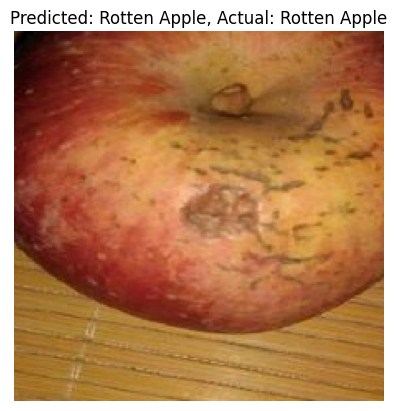

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


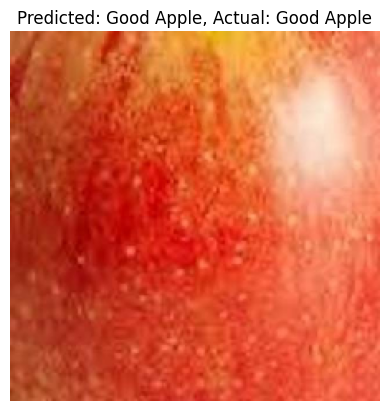

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step


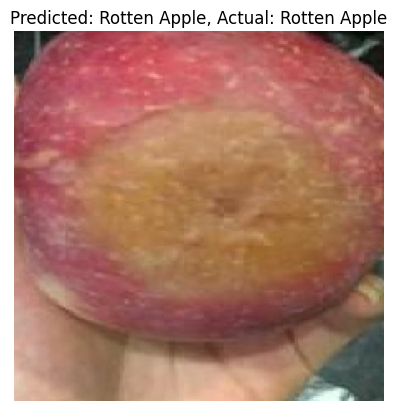

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


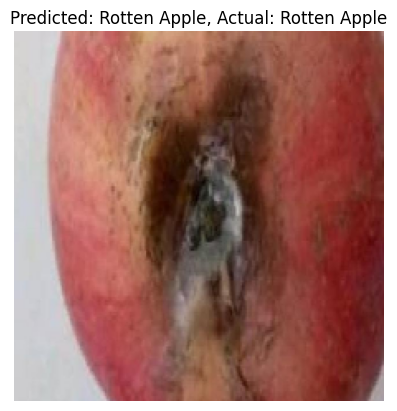

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


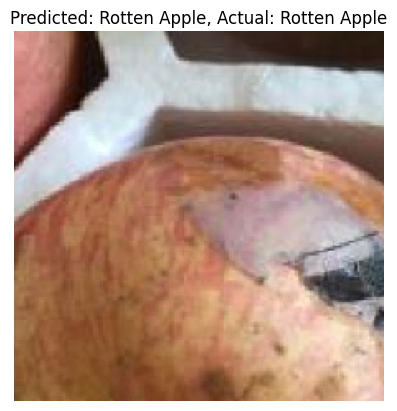

In [79]:
# 7. Inference: Predict and visualize some test images
class_labels = list(val_gen.class_indices.keys())

def plot_predictions(generator, model, num):
    for i in range(num):
        # Use the built-in next() function to get the next batch from the generator
        img, label = next(generator)
        pred = model.predict(img)
        plt.imshow(img[0])
        # Apply np.argmax to the label of the first image in the batch (label[0])
        plt.title(f"Predicted: {class_labels[np.argmax(pred[0])]}, Actual: {class_labels[np.argmax(label[0])]}")
        plt.axis('off')
        plt.show()

plot_predictions(val_gen, model,5)

In [82]:
print(acc)

0.9800000190734863


In [83]:
print(loss)

0.20350703597068787


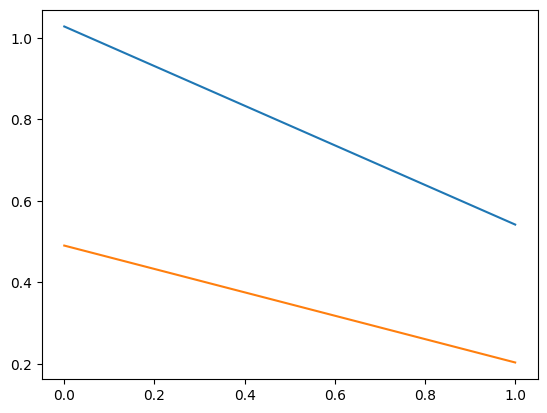

In [80]:
# Plot training & validation loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')



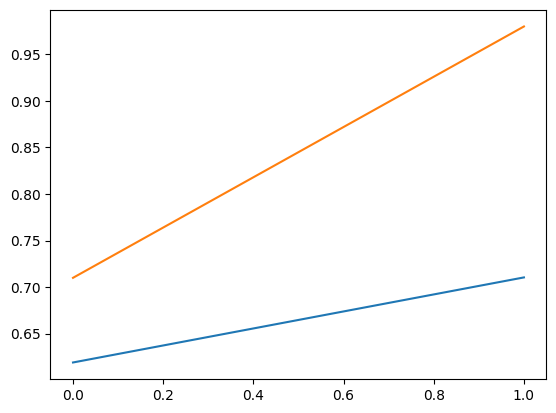

In [81]:
# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')